In [ ]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START,END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from dotenv import load_dotenv
from pyda`ntic import BaseModel,Field
from typing import Literal, TypedDict,Optional, Annotated
import operator

In [32]:
load_dotenv()

True

In [33]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [34]:
# State
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','needs_improvement']
    feedback: str
    iterations: int

    max_iterations: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [35]:
class TweetEvaluation(BaseModel):
    score: float = Field(description="Overall score from 1 to 10.")
    passed: bool = Field(description="Whether the tweet is good enough to keep.")
    humor: int = Field(description="How funny the tweet is from 1 to 10.")
    originality: int = Field(description="How fresh and non-generic the tweet feels from 1 to 10.")
    relevance: int = Field(description="How well the tweet matches the given topic from 1 to 10.")
    clarity: int = Field(description="How clear, readable, and natural the tweet is from 1 to 10.")
    compliance: bool = Field(description="Whether the tweet follows all rules.")
    issue: Optional[str] = Field(default=None, description="Main problem if the tweet is weak.")
    feedback: str = Field(description="Short improvement suggestion.")

In [36]:
def generate_tweet(state:TweetState) -> TweetState:
    topic = state['topic']

    feedback = state.get('feedback',"")
    iteration = state.get('iterations',0) + 1
    user_prompt = f"""
        Write a short, original, and hilarious tweet on topic - {topic}.

        Rules:
        - Do not use question- answer for,at.
        - Max 300 characters allowed.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day English.
        - This is version {iteration} of generating this Tweet.

        """
    if feedback: 
        user_prompt+= f"""
    Previous Iteration Feedback - {feedback}"""    

    message=[
        SystemMessage(content='You are a funny and clever Twitter/X influencer.'),
        HumanMessage(content=user_prompt)
    ]

    
    res=llm.invoke(message).content

    return {'tweet': res,'iterations': iteration, 'tweet_history':[res]}


def evaluate_tweet(state: TweetState) -> TweetState:
    topic = state["topic"]
    tweet = state["tweet"]

    messages = [
        SystemMessage(content="""
You are a strict but helpful tweet evaluator.

Your job is to judge whether the tweet is strong enough to publish for the given topic.

Evaluate using these criteria:
- Relevance: stays on topic
- Humor: actually funny, clever, or witty
- Originality: not generic, repetitive, or cliché
- Clarity: easy to read and natural sounding
- Compliance: follows the rules

Rules to check:
- Must be a short tweet
- Must be original
- Must be under 300 characters
- Must use simple everyday English
- Should use observational humor, irony, sarcasm, or cultural references when possible
- Should not sound like a generic AI sentence
- Do not rewrite the tweet unless asked
- Be fair, practical, and consistent

Return only structured output.
"""),
        HumanMessage(content=f"""
Topic: {topic}

Tweet:
{tweet}

Score the tweet and decide whether it should pass.
Use a strict standard. A tweet should only pass if it is genuinely good.
""")
    ]

    evaluator = llm.with_structured_output(TweetEvaluation)
    result = evaluator.invoke(messages)

    passed = result.passed and result.compliance and result.score >= 8

    return {
        "evaluation": "approved" if passed else "needs_improvement",
        "feedback": result.feedback,
        "score": result.score,
        "feedback_history":[result.feedback]
    }


def route_after_evaluation(state: TweetState) -> str:
    if state.get("evaluation") == "approved":
        return END

    if state.get("iterations", 0) >= state.get("max_iterations", 3):
        return END

    return 'generate'



In [37]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_after_evaluation)

workflow=graph.compile()

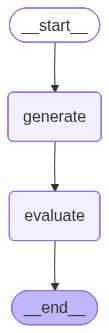

In [38]:
workflow

In [41]:
initial_state={'topic':"Software Engineer",'iterations':0, 'max_iterations':3}

output=workflow.invoke(initial_state)


In [42]:
output

{'topic': 'Software Engineer',
 'tweet': 'I told my girlfriend I’m in a relationship with my code. She said ‘commit, or else.’ Now I’m stuck in a merge conflict between dinner and deployment. #SoftwareEngineerLife',
 'evaluation': 'approved',
 'feedback': 'Great wordplay and clear punchline; could tighten phrasing slightly for sharper impact.',
 'iterations': 2,
 'max_iterations': 3,
 'tweet_history': ['Software engineers: we spend 90% of the day Googling error messages and 10% pretending we understand the code we just wrote. #debuglife',
  'I told my girlfriend I’m in a relationship with my code. She said ‘commit, or else.’ Now I’m stuck in a merge conflict between dinner and deployment. #SoftwareEngineerLife'],
 'feedback_history': ['Humor is a bit generic; try a fresher angle or a sharper punchline.',
  'Great wordplay and clear punchline; could tighten phrasing slightly for sharper impact.']}